In [2]:
import pandas as pd

# Load the dataset (assuming 'cs-training.csv' is the main training file)
df = pd.read_csv(r'C:\Users\Parth\jupyterCodes\data\cs-training.csv')

print("Raw data loaded. Preprocessing will be handled by a dedicated function.")

Raw data loaded. Preprocessing will be handled by a dedicated function.


In [3]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

def preprocess_data(df):
    print("Starting data preprocessing...")

    # Drop 'Unnamed: 0' column if it exists
    if 'Unnamed: 0' in df.columns:
        df = df.drop('Unnamed: 0', axis=1)
        print("\n'Unnamed: 0' column dropped.")

    # Identify and fill missing values using Median Imputation
    # MonthlyIncome
    median_monthly_income = df['MonthlyIncome'].median()
    df['MonthlyIncome'].fillna(median_monthly_income, inplace=True)
    print(f"\nMissing values in 'MonthlyIncome' filled with median: {median_monthly_income}")

    # NumberOfDependents
    median_dependents = df['NumberOfDependents'].median()
    df['NumberOfDependents'].fillna(median_dependents, inplace=True)
    print(f"Missing values in 'NumberOfDependents' filled with median: {median_dependents}")

    print("Median imputation completed.")

    # Define features (X) and target (y)
    X = df.drop('SeriousDlqin2yrs', axis=1)
    y = df['SeriousDlqin2yrs']

    # Feature Selection using RFE
    estimator = RandomForestClassifier(random_state=42)
    rfe_selector = RFE(estimator=estimator, n_features_to_select=7, step=1)
    rfe_selector.fit(X, y)
    selected_features = X.columns[rfe_selector.support_].tolist()
    X_selected = X[selected_features]
    print(f"\nTop 7 features selected by RFE: {selected_features}")

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42, stratify=y)
    print(f"\nOriginal training set shape (X_train, y_train): {X_train.shape, y_train.shape}")
    print(f"Original training target distribution (0: {np.sum(y_train == 0)}, 1: {np.sum(y_train == 1)})")

    # Apply SMOTE to the training data
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    print(f"Resampled training set shape (X_resampled, y_resampled): {X_resampled.shape, y_resampled.shape}")
    print(f"Resampled training target distribution (0: {np.sum(y_resampled == 0)}, 1: {np.sum(y_resampled == 1)})")
    print("SMOTE applied successfully to the training data.")

    print("Data preprocessing completed.")
    return X_resampled, y_resampled, X_test, y_test, selected_features

# Call the preprocessing function
X_resampled, y_resampled, X_test, y_test, selected_features = preprocess_data(df.copy()) # Use a copy to avoid modifying original df for potential future use

Starting data preprocessing...

'Unnamed: 0' column dropped.

Missing values in 'MonthlyIncome' filled with median: 5400.0
Missing values in 'NumberOfDependents' filled with median: 0.0
Median imputation completed.


C:\Users\Parth\AppData\Local\Temp\ipykernel_29632\852457357.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['MonthlyIncome'].fillna(median_monthly_income, inplace=True)
C:\Users\Parth\AppData\Local\Temp\ipykernel_29632\852457357.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a


Top 7 features selected by RFE: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate']

Original training set shape (X_train, y_train): ((105000, 7), (105000,))
Original training target distribution (0: 97982, 1: 7018)
Resampled training set shape (X_resampled, y_resampled): ((195964, 7), (195964,))
Resampled training target distribution (0: 97982, 1: 97982)
SMOTE applied successfully to the training data.
Data preprocessing completed.


In [9]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, auc
import matplotlib.pyplot as plt
import torch # Using torch or built-in xgb is cleaner for GPU checks than TF on Windows

param_device = {'tree_method': 'hist'}

# Initialize Base Model
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    **param_device
)

# 2. Hyperparameter Tuning
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200] # Added for better tuning
}

# n_jobs=-1 uses all CPU cores for the non-GPU parts of the grid search
grid_search = GridSearchCV(
    estimator=base_xgb, 
    param_grid=param_grid, 
    scoring='f1', 
    cv=3, 
    verbose=1, 
    n_jobs=-1
)

print("\n🚀 Starting GridSearchCV...")
grid_search.fit(X_resampled, y_resampled)

# 3. Finalization
best_xgb_model = grid_search.best_estimator_

print("-" * 30)
print(f"Best Params: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")
print("Model ready for evaluation dashboard.")


🚀 Starting GridSearchCV...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
------------------------------
Best Params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
Best F1-Score: 0.8278
Model ready for evaluation dashboard.


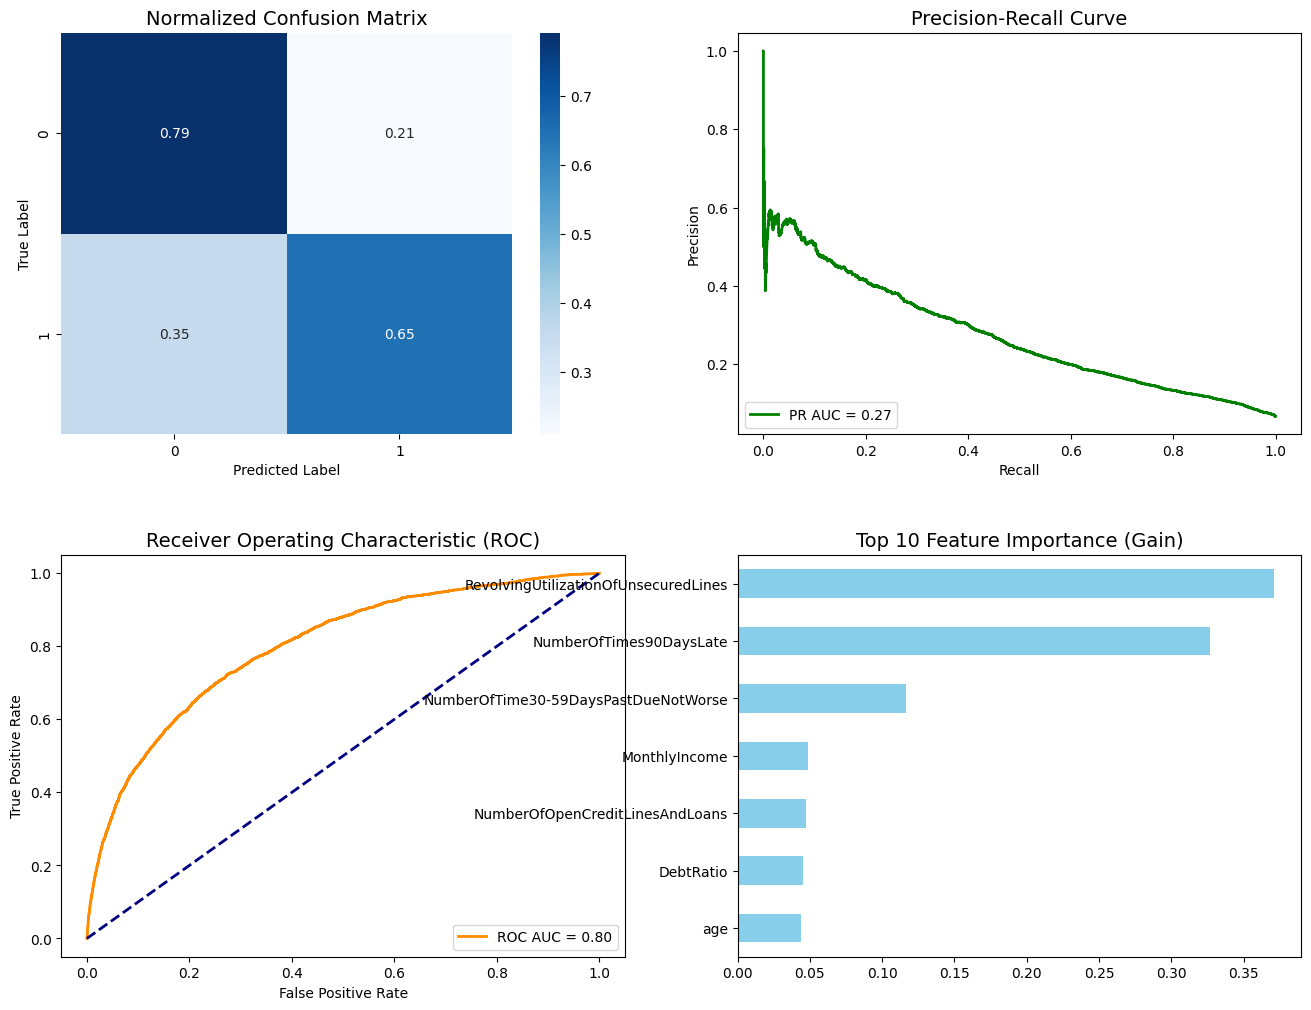


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.97      0.79      0.87     41992
           1       0.18      0.65      0.28      3008

    accuracy                           0.78     45000
   macro avg       0.58      0.72      0.58     45000
weighted avg       0.92      0.78      0.83     45000



In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc, classification_report

def plot_evaluation_dashboard(model, X_test, y_test):
    # 1. Get Predictions and Probabilities
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Create 2x2 Subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.2)

    # --- TOP LEFT: Normalized Confusion Matrix ---
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[0, 0])
    axes[0, 0].set_title('Normalized Confusion Matrix', fontsize=14)
    axes[0, 0].set_xlabel('Predicted Label')
    axes[0, 0].set_ylabel('True Label')

    # --- TOP RIGHT: Precision-Recall Curve ---
    # Critical for Credit Risk (shows tradeoff between catching defaults vs. wrong denials)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    axes[0, 1].plot(recall, precision, color='green', lw=2, label=f'PR AUC = {pr_auc:.2f}')
    axes[0, 1].set_title('Precision-Recall Curve', fontsize=14)
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].legend(loc="lower left")

    # --- BOTTOM LEFT: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.2f}')
    axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1, 0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14)
    axes[1, 0].set_xlabel('False Positive Rate')
    axes[1, 0].set_ylabel('True Positive Rate')
    axes[1, 0].legend(loc="lower right")

    # --- BOTTOM RIGHT: Feature Importance ---
    # Shows which financial behaviors (like late payments) impact the score most
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
    importances.sort_values().tail(10).plot(kind='barh', ax=axes[1, 1], color='skyblue')
    axes[1, 1].set_title('Top 10 Feature Importance (Gain)', fontsize=14)

    plt.show()

    # Print Text Metrics
    print("\n" + "="*30)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*30)
    print(classification_report(y_test, y_pred))

# Run the dashboard
# Note: Ensure X_test is your original test set (not resampled with SMOTE)
plot_evaluation_dashboard(best_xgb_model, X_test, y_test)